# Clustering géographique des communes PV en PACA

Ce notebook vise à identifier, à l’échelle de la région **PACA**, des **communes représentatives** de la production photovoltaïque en combinant une analyse **géographique** et une **pondération énergétique**.

Après le chargement et le nettoyage des données issues du registre photovoltaïque et du référentiel INSEE des communes, l’énergie annuelle injectée est **agrégée par commune**. Ces données sont ensuite enrichies par les **coordonnées géographiques (latitude, longitude)** afin de permettre une analyse spatiale.

Un **clustering géographique** est réalisé à l’aide de l’algorithme **`KMeans`**, appliqué uniquement aux coordonnées (lat, lon). Cela permet de découper la région PACA en plusieurs zones géographiques cohérentes, indépendamment du niveau de production énergétique.

Pour chaque cluster géographique, la **contribution énergétique totale** est calculée, ainsi que sa **part relative (%)** dans la production régionale. Cette information est utilisée pour caractériser le poids énergétique de chaque zone.

Dans chaque cluster, un **centre de gravité énergétique** est ensuite déterminé. Ce centroïde est calculé comme une moyenne pondérée des coordonnées géographiques, où les poids sont issus d’une **normalisation min–max de l’énergie produite par commune**, afin de limiter l’influence des valeurs extrêmes.

La **commune représentative** de chaque cluster est définie comme celle dont la position géographique est **la plus proche du centroïde énergétique**. Cette commune peut être interprétée comme un point spatialement central et énergétiquement significatif au sein de son cluster.

Enfin, les résultats sont **visualisés sur un fond de carte PACA** :  
- les communes sont affichées avec une couleur correspondant à leur cluster,  
- la taille des points est proportionnelle à leur énergie produite,  
- les communes représentatives sont mises en évidence,  
- les centroïdes KMeans sont également affichés.

Les résultats finaux sont sauvegardés dans un fichier CSV afin de permettre une exploitation ultérieure (analyse, reporting, ou comparaison avec d’autres scénarios).




### 1) Imports
Import des bibliothèques nécessaires (pandas/numpy, KMeans, matplotlib, geopandas) pour le traitement, le clustering et la cartographie.

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import geopandas as gpd

### 2) Chargement des données
Chargement des fichiers CSV (registre PV et communes INSEE), filtrage des énergies négatives, parsing des dates, suppression des doublons, et harmonisation du nom **Marseille** avec correction du code INSEE.

In [2]:
reg = pd.read_csv("registre_pv_paca_raw.csv")
comm = pd.read_csv("communes_PACA_INSEE.csv")

# On ne garde que les lignes avec énergie non négative
reg = reg[reg.energieannuelleglissanteinjectee >= 0]

# Parsing des dates
reg["datemiseenservice_date"] = pd.to_datetime(reg["datemiseenservice_date"])
reg["datemiseenservice"] = pd.to_datetime(reg["datemiseenservice"], dayfirst=True, errors="coerce")

# Nettoyage doublons
reg = reg.drop_duplicates()

# Harmonisation du nom "Marseille" et synchronisation du code INSEE
mask = reg["commune"].str.contains("marseille", case=False, na=False)
print(reg.commune.loc[mask].unique())

reg.loc[mask, "commune"] = "Marseille"
marseille_insee = comm.loc[comm.nom == "Marseille", "code_insee"].iloc[0]
reg.loc[reg.commune == "Marseille", "codeinseecommune"] = marseille_insee


['Marseille 3e Arrondissement' 'Marseille 10e Arrondissement'
 'Marseille 4e Arrondissement' 'Marseille 11e Arrondissement'
 'Marseille 14e Arrondissement' 'Marseille 16e Arrondissement'
 'Marseille 15e Arrondissement' 'Marseille 13e Arrondissement'
 'Marseille 9e Arrondissement' 'Marseille 12e Arrondissement'
 'Marseille 8e Arrondissement' 'Marseille 2e Arrondissement'
 'Marseille 5e Arrondissement' 'Marseille 7e Arrondissement']


### 3) Nettoyage / typage des colonnes
Nettoyage des types : conversion de l’énergie et des codes INSEE en formats numériques robustes (Int64), car astype("int") ne supporte pas les valeurs manquantes (NaN), tandis que astype("Int64") (type entier nullable de pandas) les gère correctement, évitant ainsi les erreurs lors des jointures et des agrégations.

In [3]:
reg["energieannuelleglissanteinjectee"] = pd.to_numeric(
    reg["energieannuelleglissanteinjectee"], errors="coerce"
)

reg["codeinseecommune"] = pd.to_numeric(
    reg["codeinseecommune"], errors="coerce"
).astype("Int64")

comm["code_insee"] = pd.to_numeric(
    comm["code_insee"], errors="coerce"
).astype("Int64")

### 4) Agrégation de l'énergie par commune
Agrégation : somme de l’énergie injectée par **commune** (code INSEE + nom), pour obtenir une énergie totale par commune.

In [4]:
agg = (
    reg.groupby(["codeinseecommune", "commune"], as_index=False)["energieannuelleglissanteinjectee"]
       .sum()
       .rename(columns={"energieannuelleglissanteinjectee": "energie_totale"})
)


### 5) Jointure avec les coordonnées géographiques
Jointure avec les coordonnées géographiques (lat/lon) des communes, suppression des communes sans coordonnées et conversion des coordonnées en float.

In [5]:
agg_geo = agg.merge(
    comm[["code_insee", "lat", "lon"]],
    left_on="codeinseecommune",
    right_on="code_insee",
    how="left"
)

agg_geo = agg_geo.dropna(subset=["lat", "lon"]).copy()
agg_geo["lat"] = agg_geo["lat"].astype(float)
agg_geo["lon"] = agg_geo["lon"].astype(float)

print("Nombre de communes avec coordonnées :", agg_geo.shape[0])


Nombre de communes avec coordonnées : 784


### 6) Clustering géographique (KMeans sur lat/lon)
Clustering géographique : application de **KMeans** sur (lat, lon) pour regrouper les communes en zones spatiales, puis attribution d’un identifiant de cluster à chaque commune.

In [6]:
X_geo = agg_geo[["lat", "lon"]].values

k_geo = 5  # nombre de clusters géographiques
kmeans_geo = KMeans(n_clusters=k_geo, random_state=42)

# Entraînement KMeans sur les données géographiques
kmeans_geo.fit(X_geo)

# Assignation du cluster à chaque commune
agg_geo["cluster_geo"] = kmeans_geo.predict(X_geo)

print("\nRépartition des communes par cluster géographique :")
print(agg_geo["cluster_geo"].value_counts())



Répartition des communes par cluster géographique :
cluster_geo
3    199
1    159
2    156
0    148
4    122
Name: count, dtype: int64


### 7) Contribution énergétique de chaque cluster
Agrégation : somme de l’énergie injectée par **commune** (code INSEE + nom), pour obtenir une énergie totale par commune.

In [7]:
cluster_energy = (
    agg_geo.groupby("cluster_geo", as_index=False)["energie_totale"]
           .sum()
           .rename(columns={"energie_totale": "energie_cluster"})
)

# Énergie totale sur toute la région
total_energy = cluster_energy["energie_cluster"].sum()

# Part de chaque cluster en %
cluster_energy["part_pourcent"] = 100 * cluster_energy["energie_cluster"] / total_energy
cluster_energy["poids"] = round(cluster_energy["part_pourcent"] / 100, 2)

print("\nContribution énergétique de chaque cluster géographique :")
print(cluster_energy)



Contribution énergétique de chaque cluster géographique :
   cluster_geo  energie_cluster  part_pourcent  poids
0            0     2.330795e+08       7.381074   0.07
1            1     9.071664e+08      28.727798   0.29
2            2     7.048656e+08      22.321413   0.22
3            3     1.129808e+09      35.778325   0.36
4            4     1.828805e+08       5.791390   0.06


## 8) Centroïde pondéré par l'énergie et commune représentative la plus proche
Pour chaque cluster :
1. Normalisation *min-max* de l'énergie totale en **poids** (afin d'éviter une domination de valeurs extrêmes).  
2. Calcul du **centre de gravité énergétique** (moyenne pondérée des coordonnées).  
3. Choix de la **commune la plus proche** de ce centre (distance euclidienne sur (lon, lat)).


In [8]:
best_communes = []

for g in agg_geo["cluster_geo"].unique():
    subset = agg_geo[agg_geo["cluster_geo"] == g].copy()

    # Poids énergétiques : min-max (attention : si max=min, la normalisation est indéfinie)
    denom = (subset["energie_totale"].max() - subset["energie_totale"].min())
    if denom == 0:
        subset["weight"] = 1.0
    else:
        subset["weight"] = (subset["energie_totale"] - subset["energie_totale"].min()) / denom

    # Centroïde pondéré (centre de gravité énergétique)
    lon_center = np.average(subset["lon"], weights=subset["weight"])
    lat_center = np.average(subset["lat"], weights=subset["weight"])

    # Distance à ce centroïde
    subset["distance"] = np.sqrt(
        (subset["lon"] - lon_center) ** 2 + (subset["lat"] - lat_center) ** 2
    )

    # Commune la plus proche du centroïde
    best_row = subset.loc[subset["distance"].idxmin()]

    best_communes.append({
        "cluster_geo": g,
        "best_commune": best_row["commune"],
        "code_insee": best_row["codeinseecommune"],
        "lat": best_row["lat"],
        "lon": best_row["lon"],
        "energie_totale": best_row["energie_totale"]
    })

best_communes_df = pd.DataFrame(best_communes)

# Ajout du poids (part énergétique) du cluster
best_communes_df = best_communes_df.merge(
    cluster_energy[["cluster_geo", "poids"]],
    on="cluster_geo",
    how="left"
)

print("\nMeilleure commune par cluster géographique (centre de gravité énergétique) :")
print(best_communes_df)



Meilleure commune par cluster géographique (centre de gravité énergétique) :
   cluster_geo            best_commune  code_insee      lat     lon  \
0            2                   Cruis        4065  44.0845  5.8397   
1            4   Saint-Étienne-le-Laus        5140  44.5075  6.1616   
2            0  Saint-Vallier-de-Thiey        6130  43.6994  6.8516   
3            1                    Bras       83021  43.4723  5.9558   
4            3              Eygalières       13034  43.7638  4.9554   

   energie_totale  poids  
0      20356525.0   0.22  
1        325158.0   0.06  
2        344281.0   0.07  
3      10603661.0   0.29  
4       1510927.0   0.36  


## 9) Chargement du fond de carte PACA
Chargement du fond de carte PACA (GeoJSON) et mise au bon système de coordonnées **WGS84 (EPSG:4326)** pour superposer correctement les points (lon/lat).

In [9]:
paca = gpd.read_file("region_paca.geojson")

# S'assurer que le fond est en WGS84 (lon, lat)
if paca.crs is None:
    paca.set_crs(epsg=4326, inplace=True)
else:
    paca = paca.to_crs(epsg=4326)


## 10) Visualisation (fond de carte PACA + clusters + communes représentatives)
Visualisation : tracé du fond de carte, affichage des communes (couleur = cluster, taille ∝ énergie), surlignage des communes représentatives et affichage des centroïdes KMeans, puis sauvegarde de la figure.

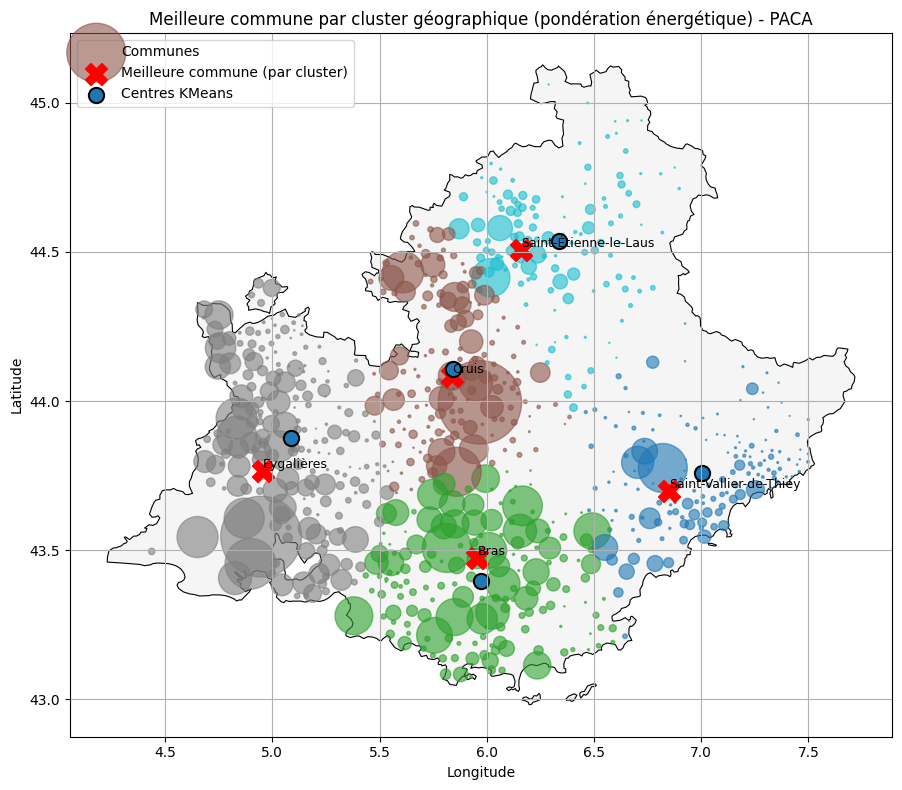

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

# Fond de carte
paca.plot(ax=ax, color="whitesmoke", edgecolor="black", linewidth=0.8)

# Taille des points proportionnelle à l'énergie (facteur de lisibilité)
point_sizes = agg_geo["energie_totale"] / 50000

# Communes
scatter_communes = ax.scatter(
    agg_geo["lon"],
    agg_geo["lat"],
    c=agg_geo["cluster_geo"],
    s=point_sizes,
    alpha=0.6,
    cmap="tab10",
    label="Communes"
)

# Meilleures communes par cluster
ax.scatter(
    best_communes_df["lon"],
    best_communes_df["lat"],
    c="red",
    s=250,
    marker="X",
    label="Meilleure commune (par cluster)"
)

# Centroïdes KMeans (attention : cluster_centers_ est [lat, lon])
centroids = kmeans_geo.cluster_centers_
plt.scatter(
    centroids[:, 1],  # lon
    centroids[:, 0],  # lat
    marker="o",
    s=120,
    edgecolors="black",
    linewidths=1.5,
    label="Centres KMeans"
)

# Annotation des noms
for _, row in best_communes_df.iterrows():
    ax.text(row["lon"], row["lat"], row["best_commune"],
            fontsize=9, ha="left", va="bottom")

ax.set_title("Meilleure commune par cluster géographique (pondération énergétique) - PACA")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True)
ax.legend(loc="upper left")

plt.savefig("carte_paca_communes.png", dpi=600, bbox_inches="tight")
plt.tight_layout()
plt.show()


## 11) Sauvegarde des résultats
Export : sauvegarde du tableau final des meilleures communes par cluster (avec poids) au format CSV.

In [12]:
best_communes_df.to_csv("best_communes_geo_energy.csv", index=False)

# Vérification
print("\nFichier sauvegardé : best_communes_geo_energy.csv")



Fichier sauvegardé : best_communes_geo_energy.csv
